# Visualization with Matplotlib, Seaborn and Plotly

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('./canadian_immegration_data.csv')
df.sample(5)

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
21,Bolivia (Plurinational State of),Latin America and the Caribbean,South America,Developing regions,44,52,42,49,38,44,...,134,139,107,143,214,180,86,83,107,3205
150,Sao Tome and Principe,Africa,Middle Africa,Developing regions,0,0,0,0,0,0,...,1,1,0,0,1,2,0,0,1,10
188,Vanuatu,Oceania,Melanesia,Developing regions,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,11
165,Suriname,Latin America and the Caribbean,South America,Developing regions,15,10,21,12,5,16,...,15,16,20,9,12,13,11,16,4,739
121,Nepal,Asia,Southern Asia,Developing regions,1,1,6,1,2,4,...,607,540,511,581,561,1392,1129,1185,1308,10222


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 39 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    195 non-null    object
 1   Continent  195 non-null    object
 2   Region     195 non-null    object
 3   DevName    195 non-null    object
 4   1980       195 non-null    int64 
 5   1981       195 non-null    int64 
 6   1982       195 non-null    int64 
 7   1983       195 non-null    int64 
 8   1984       195 non-null    int64 
 9   1985       195 non-null    int64 
 10  1986       195 non-null    int64 
 11  1987       195 non-null    int64 
 12  1988       195 non-null    int64 
 13  1989       195 non-null    int64 
 14  1990       195 non-null    int64 
 15  1991       195 non-null    int64 
 16  1992       195 non-null    int64 
 17  1993       195 non-null    int64 
 18  1994       195 non-null    int64 
 19  1995       195 non-null    int64 
 20  1996       195 non-null    int64

In [3]:
df.set_index('Country', inplace=True)
df

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Viet Nam,Asia,South-Eastern Asia,Developing regions,1191,1829,2162,3404,7583,5907,2741,...,1852,3153,2574,1784,2171,1942,1723,1731,2112,97146
Western Sahara,Africa,Northern Africa,Developing regions,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
Yemen,Asia,Western Asia,Developing regions,1,2,1,6,0,18,7,...,161,140,122,133,128,211,160,174,217,2985


In [4]:
df.iloc[:, 3:37].sample(5)

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
Senegal,13,10,9,11,7,11,16,19,17,22,...,210,278,416,433,555,668,765,740,949,818
Viet Nam,1191,1829,2162,3404,7583,5907,2741,1406,1411,3004,...,1816,1852,3153,2574,1784,2171,1942,1723,1731,2112
Ecuador,238,207,184,155,179,208,240,344,265,278,...,417,491,525,419,437,373,353,348,282,418
Ukraine,0,0,0,0,0,0,0,0,0,0,...,2431,2270,1973,2218,1937,2367,3159,2515,2265,2487
Singapore,241,301,337,169,128,139,205,372,808,1269,...,311,392,298,690,734,366,805,219,146,141


In [5]:
# Nuevo df con los años y los inmigrantes provenientes de colombia
# Columnas
print(df.columns)
print(len(df.columns))
print(list(df.columns[3:37]))

Index(['Continent', 'Region', 'DevName', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', 'Total'],
      dtype='object')
38
['1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013']


In [6]:
columnas_anos = list(df.columns[3:37])
columnas_anos

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

In [7]:
colombia = df.loc['Colombia', columnas_anos]
colombia

1980     266
1981     326
1982     360
1983     244
1984     235
1985     214
1986     257
1987     376
1988     352
1989     439
1990     614
1991     652
1992     582
1993     464
1994     375
1995     371
1996     381
1997     578
1998     929
1999    1306
2000    2259
2001    2965
2002    3283
2003    4318
2004    4566
2005    6424
2006    6535
2007    5357
2008    5452
2009    4652
2010    5218
2011    4366
2012    3741
2013    3631
Name: Colombia, dtype: object

In [8]:
# Creamos diccionario
col_dic = {
    'Year': colombia.index.tolist(),
    'Inmigrantes': colombia.values.tolist()
}
col_dic

{'Year': ['1980',
  '1981',
  '1982',
  '1983',
  '1984',
  '1985',
  '1986',
  '1987',
  '1988',
  '1989',
  '1990',
  '1991',
  '1992',
  '1993',
  '1994',
  '1995',
  '1996',
  '1997',
  '1998',
  '1999',
  '2000',
  '2001',
  '2002',
  '2003',
  '2004',
  '2005',
  '2006',
  '2007',
  '2008',
  '2009',
  '2010',
  '2011',
  '2012',
  '2013'],
 'Inmigrantes': [np.int64(266),
  np.int64(326),
  np.int64(360),
  np.int64(244),
  np.int64(235),
  np.int64(214),
  np.int64(257),
  np.int64(376),
  np.int64(352),
  np.int64(439),
  np.int64(614),
  np.int64(652),
  np.int64(582),
  np.int64(464),
  np.int64(375),
  np.int64(371),
  np.int64(381),
  np.int64(578),
  np.int64(929),
  np.int64(1306),
  np.int64(2259),
  np.int64(2965),
  np.int64(3283),
  np.int64(4318),
  np.int64(4566),
  np.int64(6424),
  np.int64(6535),
  np.int64(5357),
  np.int64(5452),
  np.int64(4652),
  np.int64(5218),
  np.int64(4366),
  np.int64(3741),
  np.int64(3631)]}

In [9]:
datos_col = pd.DataFrame(col_dic)
datos_col.sample(5)

,Year,Inmigrantes
22,2002,3283
14,1994,375
29,2009,4652
32,2012,3741
9,1989,439


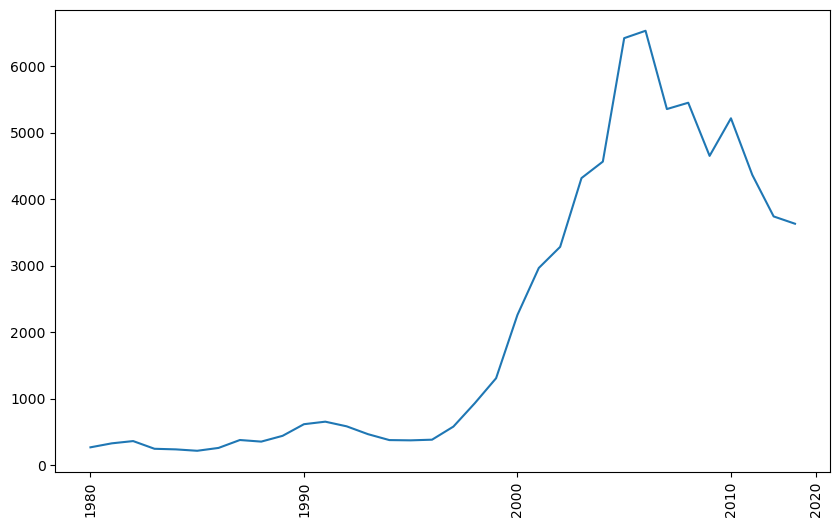

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(datos_col['Year'], datos_col['Inmigrantes'])
plt.xticks(['1980', '1990', '2000', '2010', '2020'], rotation=90)
plt.show()

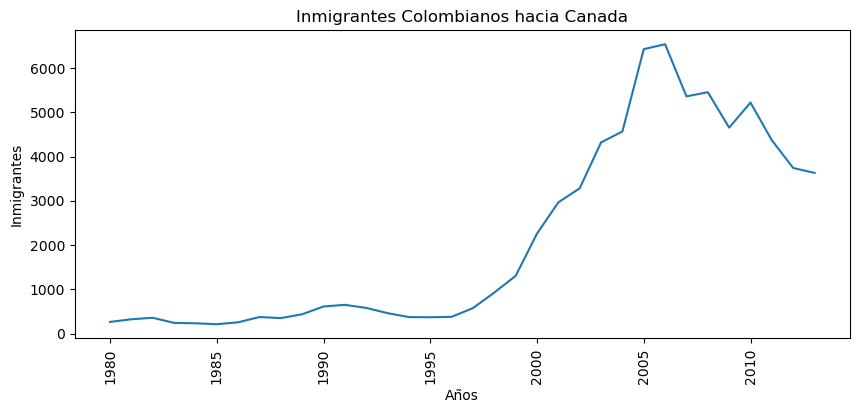

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(datos_col['Year'], datos_col['Inmigrantes'])
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'], rotation=90)
plt.xlabel('Años')
plt.ylabel('Inmigrantes')
plt.title('Inmigrantes Colombianos hacia Canada')
plt.show()

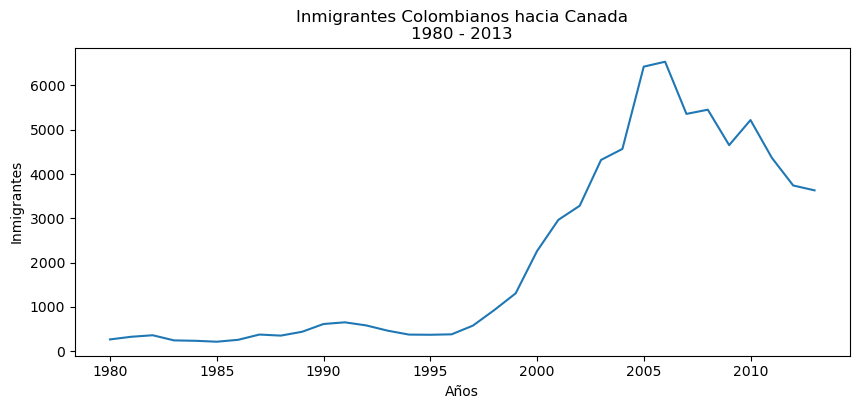

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(datos_col['Year'], datos_col['Inmigrantes'])
ax.xaxis.set_major_locator(plt.MultipleLocator(5))  # Esta linea reemplaza>> ax.set_xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
ax.set_title('Inmigrantes Colombianos hacia Canada\n1980 - 2013')
ax.set_xlabel('Años')
ax.set_ylabel('Inmigrantes')
plt.show()

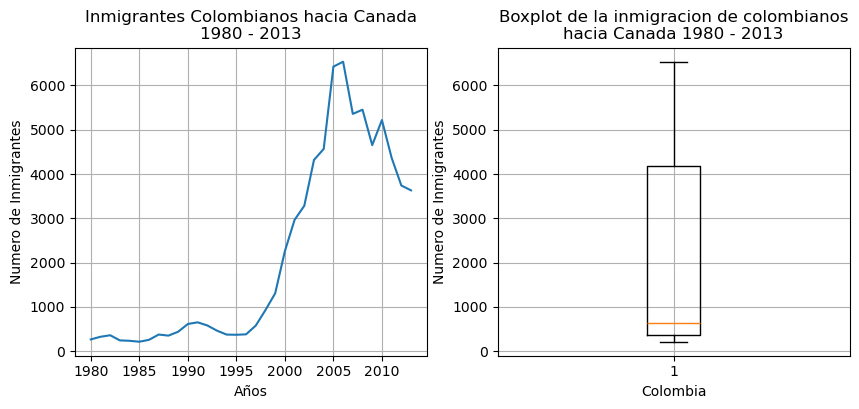

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))       # 1 fila, 2 columnas.
axs[0].plot(datos_col['Year'], datos_col['Inmigrantes'])
axs[0].set_title('Inmigrantes Colombianos hacia Canada\n1980 - 2013')
axs[0].set_xlabel('Años')
axs[0].set_ylabel('Numero de Inmigrantes')
axs[0].xaxis.set_major_locator(plt.MultipleLocator(5))
axs[0].grid()

axs[1].boxplot(datos_col['Inmigrantes'])
axs[1].set_title('Boxplot de la inmigracion de colombianos\nhacia Canada 1980 - 2013')
axs[1].set_xlabel('Colombia')
axs[1].set_ylabel('Numero de Inmigrantes')
axs[1].grid()

plt.show()

In [14]:
datos_col.describe()

,Inmigrantes
count,34.000000
mean,2120.235294
std,2163.761316
min,214.000000
25%,372.000000
50%,633.000000
75%,4173.750000
max,6535.000000


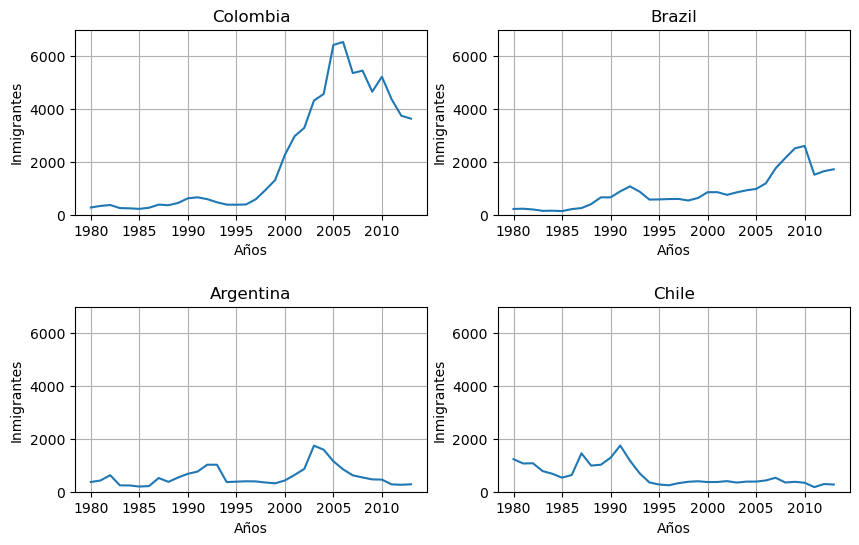

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.subplots_adjust(hspace=0.5, wspace=0.2)

# 2 filas, 2 columnas.
axs[0, 0].plot(df.loc['Colombia', columnas_anos])
axs[0, 0].set_title('Colombia')
# axs[0, 0].xaxis.set_major_locator(plt.MultipleLocator(5))
# axs[0, 0].grid()

axs[0, 1].plot(df.loc['Brazil', columnas_anos])
axs[0, 1].set_title('Brazil')

axs[1, 0].plot(df.loc['Argentina', columnas_anos])
axs[1, 0].set_title('Argentina')

axs[1, 1].plot(df.loc['Chile', columnas_anos])
axs[1, 1].set_title('Chile')

ymin = 0
ymax = 7000

for ax in axs.ravel():
    ax.set_ylim(ymin, ymax)

for ax in axs.flat:
    ax.xaxis.set_major_locator(plt.MultipleLocator(5))
    ax.set_xlabel('Años')
    ax.set_ylabel('Inmigrantes')
    ax.grid()
    

plt.show()

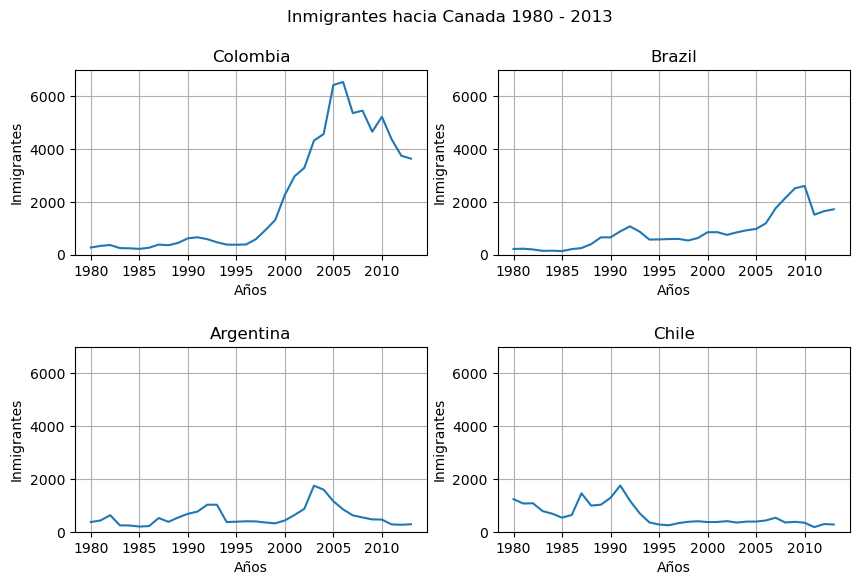

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.subplots_adjust(hspace=0.5, wspace=0.2)
fig.suptitle('Inmigrantes hacia Canada 1980 - 2013')

Paises = ['Colombia', 'Brazil', 'Argentina', 'Chile']
count = 0

ymin = 0
ymax = 7000

for ax in axs.ravel():
    ax.set_ylim(ymin, ymax)

for i in range(2):
    for j in range(2):
        axs[i, j].plot(df.loc[Paises[count], columnas_anos])
        axs[i, j].set_title(Paises[count])
        axs[i, j].xaxis.set_major_locator(plt.MultipleLocator(5))
        axs[i, j].set_xlabel('Años')
        axs[i, j].set_ylabel('Inmigrantes')
        axs[i, j].grid()
        count += 1

plt.show()

In [17]:
tiendas = ['A', 'B', 'C', 'D']
ventas_2022 = {'Ene': [100, 80, 150, 50],
    'Feb': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'May': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Sep': [240, 160, 290, 130],
    'Oct': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dec': [300, 350, 400, 250]}

df_ventas = pd.DataFrame(ventas_2022, index=tiendas)
df_ventas

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dec
A,100,120,150,180,220,230,250,260,240,220,400,300
B,80,90,100,110,190,150,170,180,160,140,220,350
C,150,170,200,230,350,280,300,310,290,270,350,400
D,50,60,80,90,200,120,140,150,130,110,190,250


In [18]:
df_ventas.loc['B']

Ene     80
Feb     90
Mar    100
Abr    110
May    190
Jun    150
Jul    170
Ago    180
Sep    160
Oct    140
Nov    220
Dec    350
Name: B, dtype: int64

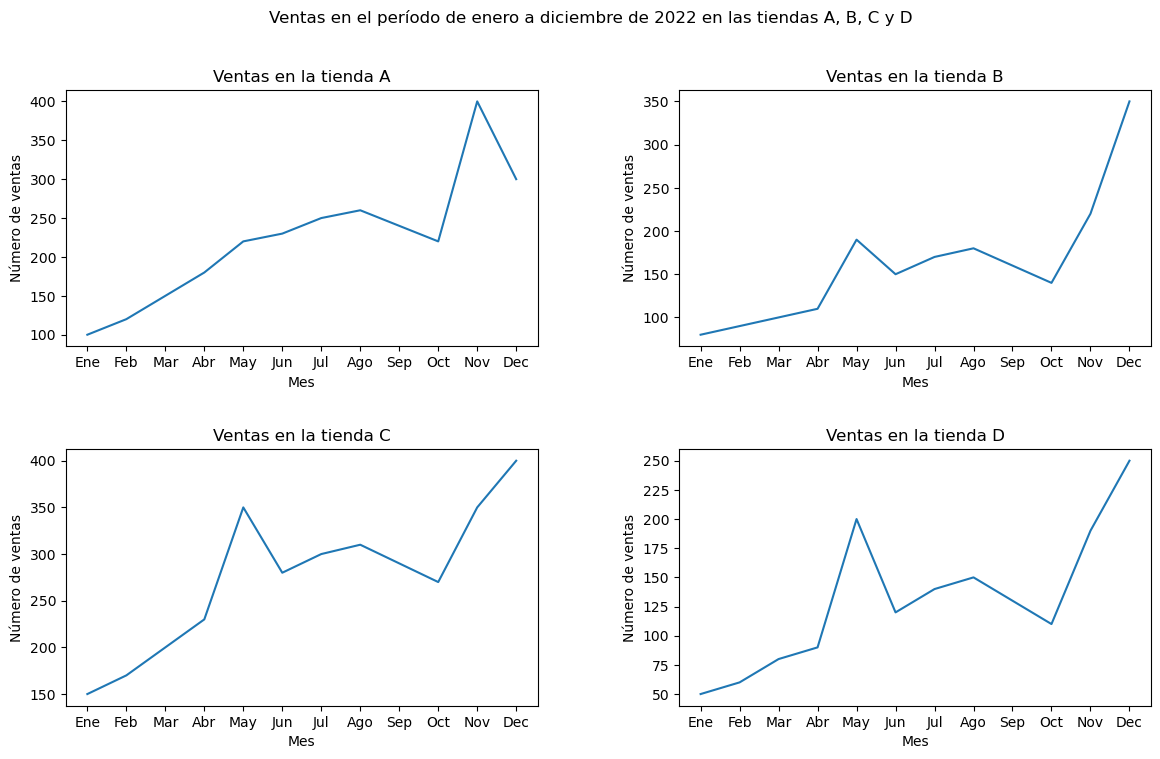

In [19]:
# Crear la figura y los subgráficos

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Ajustar los espaciados entre los subgráficos

plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Agregar un título general para los subgráficos

fig.suptitle('Ventas en el período de enero a diciembre de 2022 en las tiendas A, B, C y D')

# Agregar los gráficos en cada uno de los subgráficos

axs[0, 0].plot(df_ventas.loc['A'])
axs[0, 0].set_title('Ventas en la tienda A')
axs[0, 1].plot(df_ventas.loc['B'])
axs[0, 1].set_title('Ventas en la tienda B')
axs[1, 0].plot(df_ventas.loc['C'])
axs[1, 0].set_title('Ventas en la tienda C')
axs[1, 1].plot(df_ventas.loc['D'])
axs[1, 1].set_title('Ventas en la tienda D')

# Agregar etiquetas para los ejes X y Y

for ax in axs.flat:
    ax.set_xlabel('Mes')
    ax.set_ylabel('Número de ventas')

# Mostrar la figura

plt.show()

In [20]:
df_ventas.reset_index()

,index,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dec
0,A,100,120,150,180,220,230,250,260,240,220,400,300
1,B,80,90,100,110,190,150,170,180,160,140,220,350
2,C,150,170,200,230,350,280,300,310,290,270,350,400
3,D,50,60,80,90,200,120,140,150,130,110,190,250


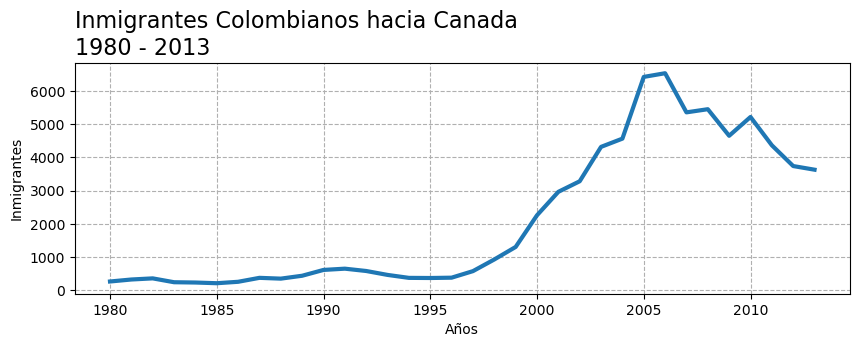

In [22]:
fig, ax = plt.subplots(figsize=(10, 3))
# plt.style.use('fivethirtyeight')
ax.plot(datos_col['Year'], datos_col['Inmigrantes'], lw=3)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))  # Esta linea reemplaza>> ax.set_xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
ax.set_title('Inmigrantes Colombianos hacia Canada\n1980 - 2013', fontsize=16, loc='left')
ax.set_xlabel('Años')
ax.set_ylabel('Inmigrantes')
ax.grid(linestyle='--')
plt.show()

In [23]:
sudamerica = df.query('Region == "South America"')
sudamerica

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Argentina,Latin America and the Caribbean,South America,Developing regions,368,426,626,241,237,196,213,...,1153,847,620,540,467,459,278,263,282,19596
Bolivia (Plurinational State of),Latin America and the Caribbean,South America,Developing regions,44,52,42,49,38,44,79,...,134,139,107,143,214,180,86,83,107,3205
Brazil,Latin America and the Caribbean,South America,Developing regions,211,220,192,139,145,130,205,...,969,1181,1746,2138,2509,2598,1508,1642,1714,29659
Chile,Latin America and the Caribbean,South America,Developing regions,1233,1069,1078,781,681,533,633,...,384,427,530,350,375,340,174,291,273,21359
Colombia,Latin America and the Caribbean,South America,Developing regions,266,326,360,244,235,214,257,...,6424,6535,5357,5452,4652,5218,4366,3741,3631,72088
Ecuador,Latin America and the Caribbean,South America,Developing regions,238,207,184,155,179,208,240,...,491,525,419,437,373,353,348,282,418,12233
Guyana,Latin America and the Caribbean,South America,Developing regions,2334,2943,3575,2650,1932,2299,3942,...,1215,1286,1277,1137,1180,953,804,676,656,75785
Paraguay,Latin America and the Caribbean,South America,Developing regions,45,26,32,40,48,36,34,...,75,88,98,95,88,89,83,55,66,1944
Peru,Latin America and the Caribbean,South America,Developing regions,317,456,401,241,306,328,628,...,1653,1473,1490,1094,1884,1283,886,787,682,32652


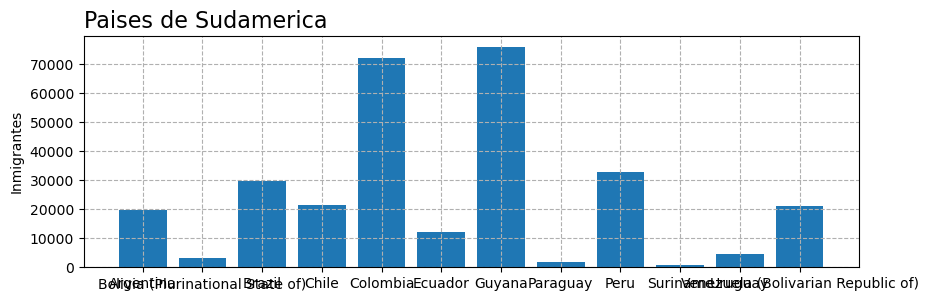

In [27]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(sudamerica.index, sudamerica['Total'])
ax.set_title('Paises de Sudamerica', loc='left', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Inmigrantes')
ax.grid(linestyle='--')
plt.show()


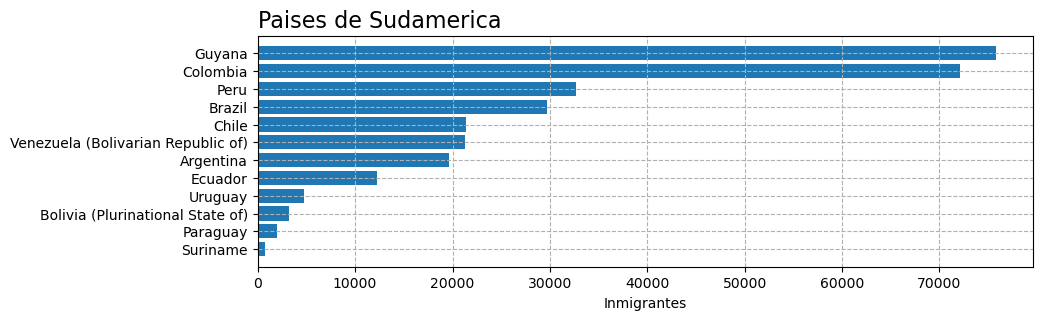

In [30]:
sudamerica_sorted = sudamerica.sort_values(by='Total', ascending=True)

fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(sudamerica_sorted.index, sudamerica_sorted['Total'])
ax.set_title('Paises de Sudamerica', loc='left', fontsize=16)
ax.set_xlabel('Inmigrantes')
ax.set_ylabel('')
ax.grid(linestyle='--')
plt.show()

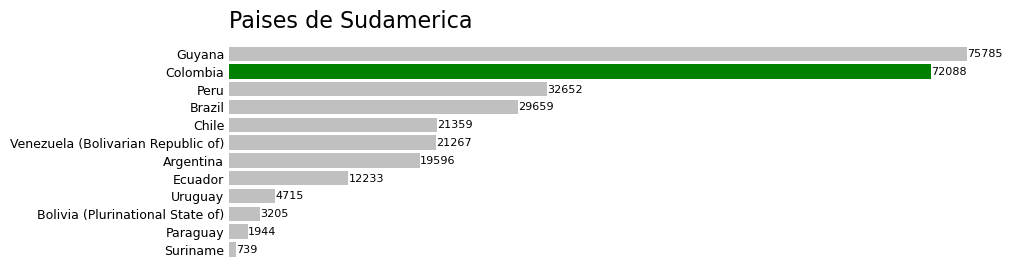

In [52]:
colores = []
for pais in sudamerica_sorted.index:
    if pais == 'Colombia':
        colores.append('green')
    else:
        colores.append('silver')
        
fig, ax = plt.subplots(figsize=(10, 3))

ax.set_frame_on(False)
ax.xaxis.set_visible(False)
#ax.yaxis.set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=9, length=0)

ax.barh(sudamerica_sorted.index, sudamerica_sorted['Total'], color=colores)
ax.set_title('Paises de Sudamerica', loc='left', fontsize=16)
# ax.set_xlabel('Inmigrantes')
ax.set_ylabel('')
# ax.grid(linestyle='--')

for i, j in enumerate(sudamerica_sorted['Total']):
    ax.text(j, i, str(j), va='center', fontsize=8)

fig.savefig('img_02.png',
            transparent=False,
            bbox_inches='tight',
            dpi=300)

plt.show()

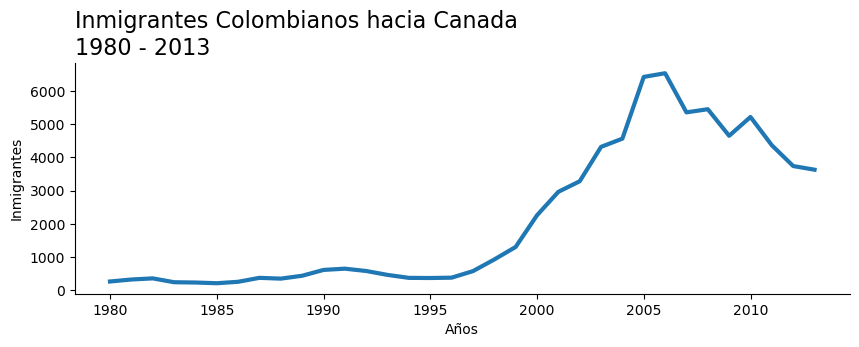

In [51]:
fig, ax = plt.subplots(figsize=(10, 3))
# plt.style.use('fivethirtyeight')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(datos_col['Year'], datos_col['Inmigrantes'], lw=3)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))  # Esta linea reemplaza>> ax.set_xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
ax.set_title('Inmigrantes Colombianos hacia Canada\n1980 - 2013', fontsize=16, loc='left')
ax.set_xlabel('Años')
ax.set_ylabel('Inmigrantes')
# ax.grid(linestyle='--')
fig.savefig('img_01.png',
            transparent=False,
            bbox_inches='tight',
            dpi=300)
plt.show()